# 🌲 Shafi Regressor (SR) : Going Beyond the Average

Welcome to this notebook! Here, we implement and explore **Shafi Regressor (SR)** from scratch and compare it with the classical Random Forest Regressor. While traditional models give you a single "point prediction," SR unlocks the entire conditional distribution of the target variable, allowing us to measure **uncertainty** mathematically.

---

## 💡 What is Quantile Regression Forest?

A classical **Random Forest Regressor** predicts the **conditional mean** ($E[Y|X]$) of the target. In simple terms, it drops a test point down all the trees, collects the values in the leaf nodes, and computes their **average**. 

However, in real-world scenarios or complex mathematical Olympiad problems, the average doesn't tell the whole story. We often need to know the bounds: *"What is the worst-case scenario ($10^{\text{th}}$ percentile) or the best-case scenario ($90^{\text{th}}$ percentile)?"*

**Shafi Regressor (SR)** solves this by keeping track of **all** training instances that land in each leaf node, not just their mean. During prediction, it builds a cumulative distribution function (CDF) from these kept values and extracts any specific quantile ($\alpha$) you request!

---

## ⚔️ QRF vs. Classical Random Forest

| Feature | Classical Random Forest | Shafi Regressor (SR) |
| :--- | :--- | :--- |
| **Output Type** | Point Prediction (Single Value) | Interval Prediction (Range/Distribution) |
| **Mathematical Target** | Conditional Mean ($E[Y \mid X]$) | Conditional Quantiles ($Q_\alpha(Y \mid X)$) |
| **Uncertainty Aware?** | ❌ No (Blind to variance) |  Yes (Gives exact error bounds) |
| **Handling Noise** | Smooths out variations | Captures heteroscedasticity (changing variance) |
| **Prediction Shape** | Rigid step-like average | Flexible boundaries adapted to local data spread |

---

## 🎯 Why is SR Better than Classical Random Forest?

1. **Uncertainty Quantification:** Instead of guessing just one number (e.g., *"The house price is $500k"*), QRF tells you *"There is a 90% chance the house price falls between $420k and $580k."*
2. **Capturing Heteroscedasticity:** In many datasets, noise isn't constant. The variance might change as $X$ increases. Classical RF completely misses this, whereas QRF's prediction intervals widen or narrow based on local data density and variance.
3. **Robustness to Outliers:** By predicting quantiles like the median ($50^{\text{th}}$ percentile) instead of the mean, the model becomes incredibly robust against extreme anomalies or noisy data points.

---

## 🚀 Use Cases: Where Should You Use QRF?

Shafi Regressor is heavily used in high-stakes industries where predicting a single number is risky:

* **Financial Risk Management:** Estimating the **Value at Risk (VaR)** for portfolio returns (e.g., *"What is the maximum loss we could face with 95% confidence?"*).
* **Supply Chain & Demand Forecasting:** Predicting future product demand. Instead of ordering the "average" amount, businesses use the $90^{\text{th}}$ percentile to prevent stockouts during peak times.
* **Weather & Energy Forecasting:** Estimating solar or wind power generation intervals to prevent power grid overloads.
* **Medical Prognosis:** Estimating the range of survival time or drug response intervals for patients based on bio-markers.

---

In [ ]:
import sys
sys.path.append('..') 

from src import ShafiRegressor

In [10]:
import numpy as np
import pickle
from sklearn.ensemble import RandomForestRegressor

class ShafiRegressor:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, random_state=None):

        self.rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=random_state
        )
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.rf.fit(X, y)
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X, quantile=0.5):
    

        leaf_indices_test = self.rf.apply(X)
        
        leaf_indices_train = self.rf.apply(self.X_train)
        
        n_samples = X.shape[0]
        predictions = np.empty(n_samples)
       
        for i in range(n_samples):
            target_leaves = leaf_indices_test[i, :]
            
            matching_train_indices = np.where(leaf_indices_train == target_leaves)[0]
            
            y_values_in_leaves = self.y_train[matching_train_indices]
            
            predictions[i] = np.quantile(y_values_in_leaves, quantile)
            
        return predictions
    def save(self, filename="shafi_regressor.pkl"):
        """saving the modle in a .pkl file"""
        with open(filename, 'wb') as file:
            pickle.dump(self, file)
        print(f"Model successfully saved to {filename}")

    @staticmethod
    def load(filename="quantile_rf_model.pkl"):
        """Loading saved pkl model"""
        with open(filename, 'rb') as file:
            model = pickle.load(file)
        print(f"Model successfully loaded from {filename}")
        return model

In [ ]:
np.random.seed(42)
X_train = np.sort(10 * np.random.rand(100, 1), axis=0)
y_train = 2 * X_train[:, 0] + np.sin(X_train[:, 0]) * 3 + np.random.normal(0, 1, 100)

original_model = ShafiRegressor(n_estimators=50, random_state=42)
original_model.fit(X_train, y_train)

original_model.save("../shafi_sr.pkl")

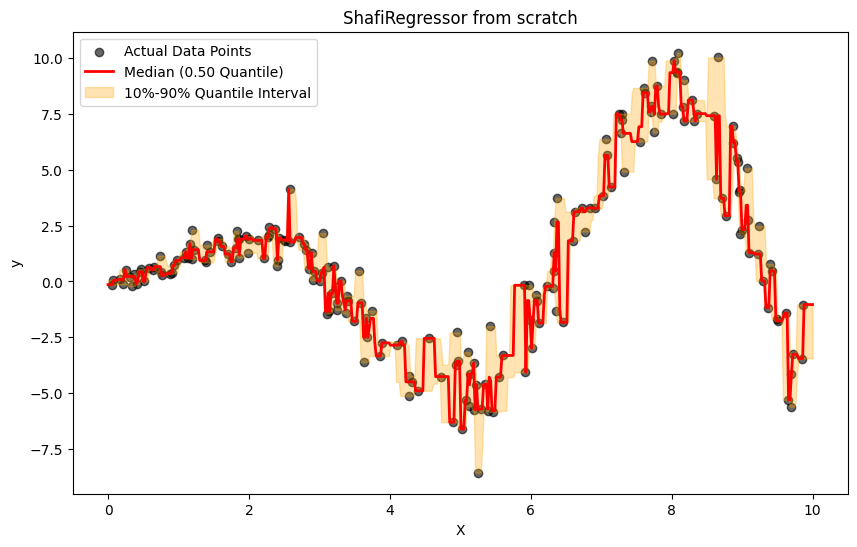

In [11]:
import matplotlib.pyplot as plt
np.random.seed(42)
X = np.sort(10 * np.random.rand(200, 1), axis=0)
    
y = np.sin(X).ravel() * X.ravel()
noise = np.random.normal(0, 0.2 + 0.2 * X.ravel())
y += noise

sr = ShafiRegressor(n_estimators=100, random_state=42)
sr.fit(X, y)
   
X_test = np.linspace(0, 10, 500).reshape(-1, 1)
    
pred_10 = sr.predict(X_test, quantile=0.10)
pred_50 = sr.predict(X_test, quantile=0.50)
pred_90 = sr.predict(X_test, quantile=0.90)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', alpha=0.6, label='Actual Data Points')
plt.plot(X_test, pred_50, color='red', lw=2, label='Median (0.50 Quantile)')
plt.fill_between(X_test.ravel(), pred_10, pred_90, color='orange', alpha=0.3, label='10%-90% Quantile Interval')
plt.title('ShafiRegressor from scratch')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [13]:
sr = ShafiRegressor(n_estimators=100, random_state=42)
sr.fit(X, y)
sr.save("shafi_sr.pkl")

Model successfully saved to shafi_sr.pkl
